In [184]:
import requests
import pandas as pd
from dotenv import load_dotenv
import os
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [185]:
load_dotenv()
API_KEY = os.getenv("CENSUS_API_KEY")

In [186]:
variables = ",".join([
    "NAME",            # County name
    "DP03_0062E",      # Median household income (in 2024 inflation-adjusted dollars).
    "DP04_0091E",      # Number of Owners with a mortgage.
    "DP04_0101E",      # Monthly Owner Costs (with a mortgage) Median (dollars).
    "DP02_0057PE",     # Percent of population 3+ Highschool enrolled in school.    
])

In [187]:
employment_variables = ",".join([
    "S2301_C01_002E",  # Population ages 16–19
    "S2301_C03_002E"   # Employment/population ratio ages 16–19
])

In [188]:
years = range(2019, 2025)

all_data = []

for year in years:

    print(f"Requesting {year}...")


    # -------------------------
    # PROFILE DATA
    # -------------------------

    profile_url = f"https://api.census.gov/data/{year}/acs/acs5/profile"

    profile_params = {
        "get": variables,
        "for": "county:*",
        "in": "state:37",
        "key": API_KEY
    }

    # -------------------------
    # EMPLOYMENT DATA
    # -------------------------

    employment_url = f"https://api.census.gov/data/{year}/acs/acs5/subject"

    employment_params = {
        "get": employment_variables,
        "for": "county:*",
        "in": "state:37",
        "key": API_KEY
    }

    try:

        # Get profile data
        profile_response = requests.get(
            profile_url,
            params=profile_params,
            timeout=10
        )

        # Get employment data
        employment_response = requests.get(
            employment_url,
            params=employment_params,
            timeout=10
        )

        print(
            f"Profile: {profile_response.status_code} | "
            f"Employment: {employment_response.status_code}"
        )

        if profile_response.status_code == 200 and employment_response.status_code == 200:

            # Convert profile response to dataframe
            profile_data = profile_response.json()

            profile_df = pd.DataFrame(
                profile_data[1:],
                columns=profile_data[0]
            )

            # Convert employment response to dataframe
            employment_data = employment_response.json()

            employment_df = pd.DataFrame(
                employment_data[1:],
                columns=employment_data[0]
            )

            # Merge using state + county
            df_year = profile_df.merge(
                employment_df,
                on=["state", "county"],
                how="left"
            )

            # Add year
            df_year["year"] = year

            all_data.append(df_year)

            print(f"{year} complete!")

        else:
            print(f"{year}: Error")

    except requests.exceptions.Timeout:
        print(f"{year}: Request timed out")

    except requests.exceptions.RequestException as e:
        print(f"{year}: Request failed - {e}")

Requesting 2019...
Profile: 200 | Employment: 200
2019 complete!
Requesting 2020...
Profile: 200 | Employment: 200
2020 complete!
Requesting 2021...
Profile: 200 | Employment: 200
2021 complete!
Requesting 2022...
Profile: 200 | Employment: 200
2022 complete!
Requesting 2023...
Profile: 200 | Employment: 200
2023 complete!
Requesting 2024...
Profile: 200 | Employment: 200
2024 complete!


In [189]:
df = pd.concat(all_data, ignore_index=True)
df.head()

,NAME,DP03_0062E,DP04_0091E,DP04_0101E,DP02_0057PE,state,county,S2301_C01_002E,S2301_C03_002E,year
0,"Haywood County, North Carolina",51659,10353,1199,23.6,37,087,2618,38.2,2019
1,"Forsyth County, North Carolina",51569,58913,1216,21.3,37,067,22282,25.4,2019
2,"Bertie County, North Carolina",35527,2591,1083,23.6,37,015,821,26.9,2019
3,"Bladen County, North Carolina",36173,4112,1070,26.8,37,017,1796,32.4,2019
4,"Carteret County, North Carolina",57194,11960,1422,21.8,37,031,2844,38.6,2019


In [190]:
attendance_df = pd.read_csv("CLT.AVG.Attendance.csv")
absent_df = pd.read_csv("CLT.AVG.Absent.csv")

In [191]:
df = df.merge(
    attendance_df,
    on="year",
    how="left"
)

In [192]:
df = df.merge(
    absent_df,
    on="year",
    how="left"
)

In [193]:
#Checking the data/cleaning it.
print(df["year"].unique())
print(absent_df["year"].unique())

[2019 2020 2021 2022 2023 2024]
[2013 2014 2015 2016 2017 2018 2019 2021 2022 2023 2024 2025]


In [194]:
#Dropping nan values for absent_avg_percentage since were missing all of 2020 for the entire data set. This will allow us to run the regression model without errors.
df = df.dropna(subset=["absent_avg_percentage"])

In [195]:
df[df["absent_avg_percentage"].isna()][["year", "absent_avg_percentage"]]

,year,absent_avg_percentage


In [196]:
df.head()

,NAME,DP03_0062E,DP04_0091E,DP04_0101E,DP02_0057PE,state,county,S2301_C01_002E,S2301_C03_002E,year,attendanceatHomeshcool_avg_percentage,absent_avg_percentage
0,"Haywood County, North Carolina",51659,10353,1199,23.6,37,087,2618,38.2,2019,74.54,14.0
1,"Forsyth County, North Carolina",51569,58913,1216,21.3,37,067,22282,25.4,2019,74.54,14.0
2,"Bertie County, North Carolina",35527,2591,1083,23.6,37,015,821,26.9,2019,74.54,14.0
3,"Bladen County, North Carolina",36173,4112,1070,26.8,37,017,1796,32.4,2019,74.54,14.0
4,"Carteret County, North Carolina",57194,11960,1422,21.8,37,031,2844,38.6,2019,74.54,14.0


In [197]:
numeric_cols = [
    #"NAME",            # County name
    "DP03_0062E",      # Income_Median
    "DP04_0091E",      # Owners_with_Mortgage
    "DP04_0101E",      # Median_Owner_Costs
    "DP02_0057PE",     # Highschool_Enrolled_Percent
    "S2301_C01_002E",  # Population ages 16–19
    "S2301_C03_002E"   # Employment/population ratio ages 16–19
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce") # coerce -> If something cannot be converted to a number, don’t crash. Instead, turn it into NaN.

df = df.rename(columns={
    #"NAME": "County_Name",
    "DP03_0062E": "Income_Median",
    "DP04_0091E": "Owners_with_Mortgage",
    "DP04_0101E": "Median_Owner_Costs",
    "DP02_0057PE": "Highschool_Enrolled_Percent",
    "S2301_C01_002E": "Population_16_19",
    "S2301_C03_002E": "Employment_Ratio_16_19"
})

df.head()

,NAME,Income_Median,Owners_with_Mortgage,Median_Owner_Costs,Highschool_Enrolled_Percent,state,county,Population_16_19,Employment_Ratio_16_19,year,attendanceatHomeshcool_avg_percentage,absent_avg_percentage
0,"Haywood County, North Carolina",51659,10353,1199,23.6,37,087,2618,38.2,2019,74.54,14.0
1,"Forsyth County, North Carolina",51569,58913,1216,21.3,37,067,22282,25.4,2019,74.54,14.0
2,"Bertie County, North Carolina",35527,2591,1083,23.6,37,015,821,26.9,2019,74.54,14.0
3,"Bladen County, North Carolina",36173,4112,1070,26.8,37,017,1796,32.4,2019,74.54,14.0
4,"Carteret County, North Carolina",57194,11960,1422,21.8,37,031,2844,38.6,2019,74.54,14.0


In [198]:
df.isnull().sum()

NAME                                     0
Income_Median                            0
Owners_with_Mortgage                     0
Median_Owner_Costs                       0
Highschool_Enrolled_Percent              0
state                                    0
county                                   0
Population_16_19                         0
Employment_Ratio_16_19                   0
year                                     0
attendanceatHomeshcool_avg_percentage    0
absent_avg_percentage                    0
dtype: int64

In [199]:
print(df.columns.tolist())

['NAME', 'Income_Median', 'Owners_with_Mortgage', 'Median_Owner_Costs', 'Highschool_Enrolled_Percent', 'state', 'county', 'Population_16_19', 'Employment_Ratio_16_19', 'year', 'attendanceatHomeshcool_avg_percentage', 'absent_avg_percentage']


In [200]:
yearly_avg = df.groupby("year")[[
    "Income_Median",
    "Owners_with_Mortgage",
    "Median_Owner_Costs",
    "Highschool_Enrolled_Percent",
    "Population_16_19",
    "Employment_Ratio_16_19",
    "attendanceatHomeshcool_avg_percentage",
    "absent_avg_percentage"
]].mean()

yearly_avg

,Income_Median,Owners_with_Mortgage,Median_Owner_Costs,Highschool_Enrolled_Percent,Population_16_19,Employment_Ratio_16_19,attendanceatHomeshcool_avg_percentage,absent_avg_percentage
year,,,,,,,,
2019,48419.49,16336.99,1196.55,22.841,5520.01,31.036,74.54,14.00
2021,53090.87,16611.83,1249.68,22.758,5651.68,32.423,75.45,20.83
2022,58261.46,16904.66,1345.87,22.677,5680.06,33.921,61.00,26.49
2023,61072.21,17217.52,1394.40,22.761,5667.36,34.001,61.97,22.00
2024,63181.72,17487.90,1451.38,22.749,5738.57,34.741,62.00,20.01


In [201]:
#Create a correlation matrix
correlation_matrix = yearly_avg.corr()
correlation_matrix

,Income_Median,Owners_with_Mortgage,Median_Owner_Costs,Highschool_Enrolled_Percent,Population_16_19,Employment_Ratio_16_19,attendanceatHomeshcool_avg_percentage,absent_avg_percentage
Income_Median,1.000000,0.984086,0.992375,-0.612593,0.910520,0.987495,-0.888082,0.603669
Owners_with_Mortgage,0.984086,1.000000,0.993698,-0.480354,0.879944,0.953583,-0.834697,0.456729
Median_Owner_Costs,0.992375,0.993698,1.000000,-0.547743,0.881897,0.972730,-0.888814,0.521617
Highschool_Enrolled_Percent,-0.612593,-0.480354,-0.547743,1.000000,-0.745161,-0.721734,0.669922,-0.971882
Population_16_19,0.910520,0.879944,0.881897,-0.745161,1.000000,0.944750,-0.710623,0.696434
Employment_Ratio_16_19,0.987495,0.953583,0.972730,-0.721734,0.944750,1.000000,-0.895184,0.695949
attendanceatHomeshcool_avg_percentage,-0.888082,-0.834697,-0.888814,0.669922,-0.710623,-0.895184,1.000000,-0.663516
absent_avg_percentage,0.603669,0.456729,0.521617,-0.971882,0.696434,0.695949,-0.663516,1.000000


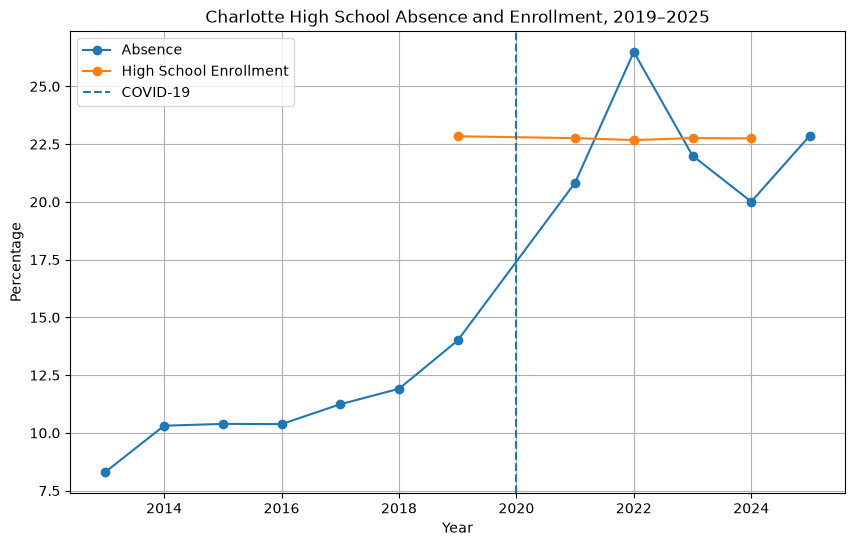

In [202]:
import matplotlib.pyplot as plt

# Sort data
absent_df = absent_df.sort_values("year")

# Calculate yearly average high school enrollment
enrollment_yearly = df.groupby("year")["Highschool_Enrolled_Percent"].mean()

plt.figure(figsize=(10, 6))

# Absence
plt.plot(
    absent_df["year"],
    absent_df["absent_avg_percentage"],
    marker="o",
    label="Absence"
)

# High school enrollment
plt.plot(
    enrollment_yearly.index,
    enrollment_yearly,
    marker="o",
    label="High School Enrollment"
)

# COVID-19
plt.axvline(
    x=2020,
    linestyle="--",
    label="COVID-19"
)

plt.title("Charlotte High School Absence and Enrollment, 2019–2025")
plt.xlabel("Year")
plt.ylabel("Percentage")

plt.legend()
plt.grid(True)

plt.savefig(
    "absence_enrollment_plot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig("absence_enrollment_plot.png", dpi=300, bbox_inches="tight")
plt.show()

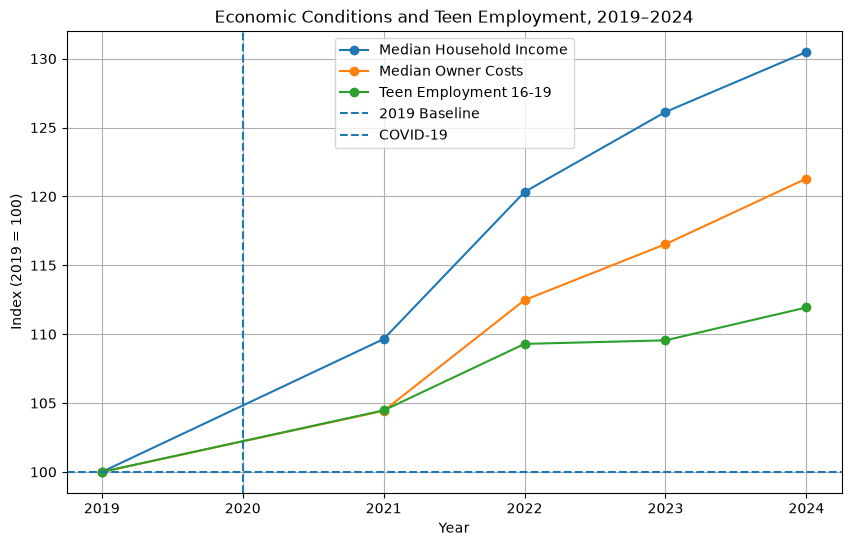

In [203]:

# Creates an indexed plot for the economic conditions and teen employment data, using 2019 as the baseline (100) because theres idfference measured values.
indexed = yearly_avg[[
    "Income_Median",
    "Median_Owner_Costs",
    "Employment_Ratio_16_19"
]].div(
    yearly_avg[[
        "Income_Median",
        "Median_Owner_Costs",
        "Employment_Ratio_16_19"
    ]].iloc[0]
).mul(100)

plt.figure(figsize=(10, 6))

plt.plot(
    indexed.index,
    indexed["Income_Median"],
    marker="o",
    label="Median Household Income"
)

plt.plot(
    indexed.index,
    indexed["Median_Owner_Costs"],
    marker="o",
    label="Median Owner Costs"
)

plt.plot(
    indexed.index,
    indexed["Employment_Ratio_16_19"],
    marker="o",
    label="Teen Employment 16-19"
)

plt.axhline(
    y=100,
    linestyle="--",
    label="2019 Baseline"
)

plt.axvline(
    x=2020,
    linestyle="--",
    label="COVID-19"
)

plt.title("Economic Conditions and Teen Employment, 2019–2024")
plt.xlabel("Year")
plt.ylabel("Index (2019 = 100)")
plt.legend()
plt.grid(True)
plt.savefig("economic_conditions_teen_employment.png", dpi=300, bbox_inches="tight")
plt.show()